In [1]:
import pandas as pd

In [3]:
from nsepy import get_history as gh
import datetime as dt

In [4]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2021,12,28)
stk_data = gh(symbol='TATACOFFEE',start=start,end=end)


In [5]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data.to_csv("Tatacoffee13_21.csv")

In [6]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[["Open"]])
print("Len:",data1.shape)

Len: (2225, 1)


In [7]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [22]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
orders=[(0,1,2),(1,2,3)]
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    #print(i)
   
    for td in trends:
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
        from sklearn.metrics import r2_score
        mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

Lag=1,Trend=n
RMSE-Testset: 0.06122516432522072
maPe-Testset: 54422108483.67414
************
Lag=1,Trend=t
RMSE-Testset: 0.06543048570478902
maPe-Testset: 52604273771.40301
************
Lag=1,Trend=c
RMSE-Testset: 0.037001898622511464
maPe-Testset: 66653037057.74459
************
Lag=1,Trend=ct
RMSE-Testset: 0.17818975787556177
maPe-Testset: 3507406966.695782
************
Lag=2,Trend=n
RMSE-Testset: 0.06106675858371923
maPe-Testset: 57517439599.55056
************
Lag=2,Trend=t
RMSE-Testset: 0.0667554267145479
maPe-Testset: 55068901298.4631
************
Lag=2,Trend=c
RMSE-Testset: 0.04085794119506278
maPe-Testset: 67559716718.50176
************
Lag=2,Trend=ct
RMSE-Testset: 0.16796781745470096
maPe-Testset: 12114961894.108156
************
Lag=3,Trend=n
RMSE-Testset: 0.06119995654965894
maPe-Testset: 60061261442.37218
************
Lag=3,Trend=t
RMSE-Testset: 0.05761208050417839
maPe-Testset: 61708504725.457664
************


C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
 

Lag=3,Trend=c
RMSE-Testset: 0.03886769691786532
maPe-Testset: 71931783183.8089
************
Lag=3,Trend=ct
RMSE-Testset: 0.14977736326941798
maPe-Testset: 21647617716.972282
************
Lag=4,Trend=n
RMSE-Testset: 0.06118669797586589
maPe-Testset: 60615232545.289314
************
Lag=4,Trend=t
RMSE-Testset: 0.05733281576418694
maPe-Testset: 62390177846.37078
************
Lag=4,Trend=c
RMSE-Testset: 0.03901022179093271
maPe-Testset: 72421093193.38321
************
Lag=4,Trend=ct
RMSE-Testset: 0.14853302066246313
maPe-Testset: 22613805391.158016
************


C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
 

In [23]:
len(y_pred)

445

In [14]:
i=1
td='c'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred,squared=False)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=1,Trend=c
RMSE-Testset: 0.037001898622511464
maPe-Testset: 66653037057.74459
************


C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,


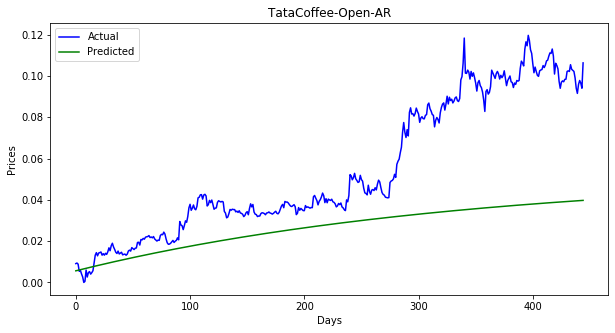

In [12]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Open-AR","Days","Prices")

In [11]:
len(data1)

2225

In [24]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,["Open"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Open"])

In [25]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Open"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Open"])

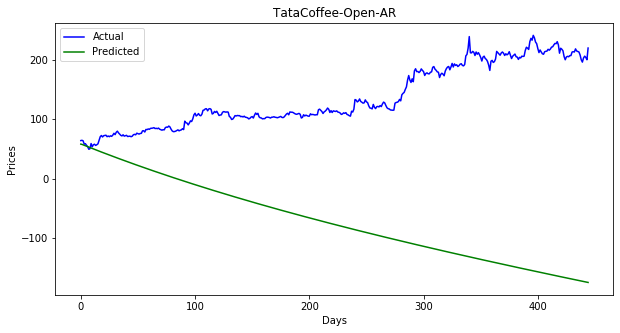

In [28]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Open-AR","Days","Prices")

In [27]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 237.89048589300097
maPe-Testset: 1.3956725955360432


In [30]:
forecast=model_fit.predict(len(data1), len(data1)+30)

In [ ]:
forecast

In [32]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Openfore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Openfore"])

In [35]:
forecast_stock_price_test_oriF

,Openfore
0,-175.065
1,-175.464
2,-175.862
3,-176.261
4,-176.659
5,-177.057
6,-177.455
7,-177.852
8,-178.249
9,-178.646


In [ ]:
forecast_stock_price_test_oriF.to_csv("OpenAR.csv",index=False)